In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
path = kagglehub.dataset_download("wcukierski/enron-email-dataset")

print("Path to dataset files:", path)

100%|██████████| 358M/358M [00:03<00:00, 107MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wcukierski/enron-email-dataset/versions/2


In [3]:
df=pd.read_csv(path + "/emails.csv")

In [4]:
df.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [5]:
df.tail()

,file,message
517396,zufferli-j/sent_items/95.,Message-ID: <26807948.1075842029936.JavaMail.e...
517397,zufferli-j/sent_items/96.,Message-ID: <25835861.1075842029959.JavaMail.e...
517398,zufferli-j/sent_items/97.,Message-ID: <28979867.1075842029988.JavaMail.e...
517399,zufferli-j/sent_items/98.,Message-ID: <22052556.1075842030013.JavaMail.e...
517400,zufferli-j/sent_items/99.,Message-ID: <28618979.1075842030037.JavaMail.e...


**NPL**
cleaning the data
created data

In [6]:
# basic function for cleaning emails using regex
def clean_email(text):
  text =text.lower()
  text = re.sub(r'subject:.*', '', text)
  text = re.sub(r'from:.*', '', text)
  text = re.sub(r'to:.*', '', text)
  text = re.sub(r'https\S+:.*', '', text)
  text = re.sub(r'\S+@\S+.*', '', text)
  text = re.sub(r'[^a-z\s]:.*', '', text)
  text = re.sub(r'[\s+]', '', text)
  return text.strip()

In [7]:
# rule - based labelling
def label_email(text):
  if any (i in text for i in ['meeting','schedule','agenda']):
     return 3 #'meeting'
  elif any(word in text for word in['offer','free','discount','deal']):
    return 2 # promotion
  elif any(word in text for word in ['family','friend','dinner','personal']):
    return 1 # personal;
  else:
    return 0 #buisness

In [8]:
texts =[]
labels=[]
for msg in df['message'].astype(str).head(4000):
  clean =clean_email(msg)
  texts.append(clean)
  labels.append(label_email(clean))

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

In [10]:
tokenizer = Tokenizer(num_words=4000,oov_token='<OOV>')
tokenizer.fit_on_texts(texts)


word => vetors / numbers

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
sequences = tokenizer.texts_to_sequences(texts)
X=pad_sequences(sequences , maxlen=50)
y= np.array(labels)


In [12]:
# trian test split
from sklearn.model_selection import train_test_split
# train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model 1 rnn

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,LSTM ,GRU # simplernn lstm gru from this lib

In [14]:
model_rnn = Sequential([
    Embedding(4000, 64, input_length=50),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(4,activation='softmax')
])# embedding  layer , simpleRNN  - units ,droppout ,output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [16]:
model_rnn.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
model_rnn.fit(X_train,y_train,epochs=10,validation_split=0.2,callbacks=[early_stop])

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6377 - loss: 0.9959 - val_accuracy: 0.7516 - val_loss: 0.6819
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8131 - loss: 0.5948 - val_accuracy: 0.8359 - val_loss: 0.5492
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8919 - loss: 0.4057 - val_accuracy: 0.8203 - val_loss: 0.5158
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9213 - loss: 0.3013 - val_accuracy: 0.8641 - val_loss: 0.4698
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9328 - loss: 0.2273 - val_accuracy: 0.8594 - val_loss: 0.4583
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9492 - loss: 0.1719 - val_accuracy: 0.8547 - val_loss: 0.4892
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9659 - loss: 0.1196 - val_accuracy: 0.8625 - val_loss: 0.5346
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9639 - loss: 0.1216 - val_accuracy: 0.8281 - v

In [18]:
rnn_loss,rnn_acc = model_rnn.evaluate(X_test,y_test)
# Note: There's a TypeError in cell sNnFktnQo2MQ. The keyword 'moniter' in EarlyStopping should be 'monitor'.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8102 - loss: 0.5630


model 2 lstm

In [19]:
model_lstm = Sequential([
    Embedding(4000,64),
    LSTM(64),
    Dropout(0.3),
    Dense(4,activation="softmax")
]) #Embedding layers,SimpleRNN - Units,Dropout,Output


model_lstm.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])


model_lstm.fit(X_train,y_train,epochs=10,validation_split=0.2,callbacks=[early_stop])

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6354 - loss: 1.0929 - val_accuracy: 0.7297 - val_loss: 0.7621
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7407 - loss: 0.7497 - val_accuracy: 0.7609 - val_loss: 0.6627
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7634 - loss: 0.6807 - val_accuracy: 0.8062 - val_loss: 0.5774
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8257 - loss: 0.5188 - val_accuracy: 0.8344 - val_loss: 0.5078
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8683 - loss: 0.4166 - val_accuracy: 0.8047 - val_loss: 0.5879
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8666 - loss: 0.4206 - val_accuracy: 0.8500 - val_loss: 0.4770
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8938 - loss: 0.3450 - val_accuracy: 0.8594 - val_loss: 0.4817
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9111 - loss: 0.3134 - val_accuracy: 0.8609 - v

In [20]:
lstm_loss,lstm_acc = model_lstm.evaluate(X_test,y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8487 - loss: 0.5011


model 3: GRU

In [21]:
model_gru = Sequential([
    Embedding(4000,64),
    GRU(64),
    Dropout(0.3),
    Dense(4,activation="softmax")
]) #Embedding layers,SimpleRNN - Units,Dropout,Output


model_gru.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])


model_gru.fit(X_train,y_train,epochs=10,validation_split=0.2,callbacks=[early_stop])

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6442 - loss: 1.1147 - val_accuracy: 0.6984 - val_loss: 0.7539
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7169 - loss: 0.7924 - val_accuracy: 0.7734 - val_loss: 0.6295
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7704 - loss: 0.6326 - val_accuracy: 0.8031 - val_loss: 0.6053
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8264 - loss: 0.5226 - val_accuracy: 0.8375 - val_loss: 0.5413
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8586 - loss: 0.4098 - val_accuracy: 0.8438 - val_loss: 0.5399
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8807 - loss: 0.3715 - val_accuracy: 0.8531 - val_loss: 0.5956
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8962 - loss: 0.3170 - val_accuracy: 0.8562 - val_loss: 0.5586
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9033 - loss: 0.2778 - val_accuracy: 0.8672 - v

In [22]:
gru_loss,gru_acc = model_gru.evaluate(X_test,y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8331 - loss: 0.6142


In [23]:
#Evaluating the models
rnn_loss,rnn_acc = model_rnn.evaluate(X_test,y_test)
lstm_loss,lstm_acc = model_lstm.evaluate(X_test,y_test)
gru_loss,gru_acc = model_gru.evaluate(X_test,y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8102 - loss: 0.5630
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8487 - loss: 0.5011
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8331 - loss: 0.6142


In [24]:
accuracies = {"RNN":rnn_acc,"LSTM":lstm_acc,"GRU":gru_acc}

In [25]:
best_model = max(accuracies)
best_model

'RNN'

In [26]:
accuracies={
    'RNN':rnn_acc,
    'LSTM':lstm_acc,
    'GRU':gru_acc
}

Text(0, 0.5, 'Accuracy')

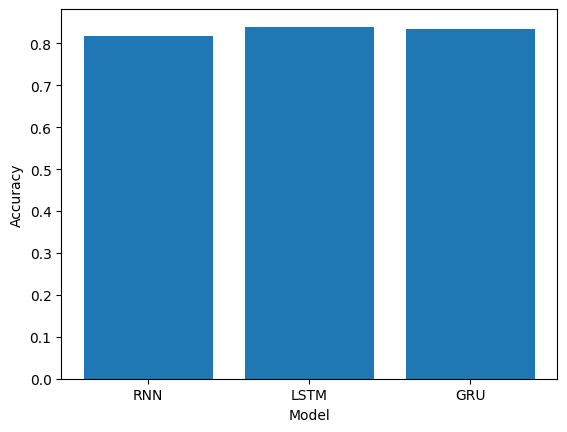

In [27]:
plt.bar(accuracies.keys(),accuracies.values())
plt.xlabel('Model')
plt.ylabel('Accuracy')

In [28]:
# save the best model
model_rnn.save('email_classifer.h5')